# SGC vs GCN Benchmark Harness with Homophily Experiment

Runs both models on Cora / Citeseer / Pubmed across multiple seeds and produces a comparison table.

**Outputs per run:** test acc, val acc, best epoch, wall-clock training time, full loss/accuracy curves.

**Outputs aggregated:** mean ± std test accuracy and training time per (model, dataset).

## Homophily Experiment (See section 8. Independent Exploration)

As an independent exploration, we investigated whether graph homophily predicts test accuracy for both SGC and GCN. The motivation was to test the assumption underlying SGC: that neighborhood smoothing is effective because connected nodes share the same label (homophily).

We extended the benchmark to 7 datasets spanning a range of homophily ratios: three homophilic citation networks (Cora, Citeseer, Pubmed) and four heterophilic datasets (Actor, Chameleon, Squirrel, Amazon-ratings). These datasets were chosen based on their size, and number of classes (in the same range of the citation networks). Homophily ratios were computed directly from each dataset's edge structure as the fraction of edges connecting nodes of the same class.

Both SGC and GCN were run on all 7 datasets using 10 random seeds. A Pearson correlation was computed between homophily ratio and mean test accuracy for each model. We found that both models show a significant positive correlation between homophily and accuracy: SGC (r=0.84, p=0.018) and GCN (r=0.98, p=0.0001). Notably GCN's accuracy is more tightly correlated with homophily than SGC's, suggesting SGC is more robust to heterophilic graphs than expected. Results are visualized as a scatter plot with trend lines for each model.

Note: Chameleon and Squirrel have been flagged for label leakage in standard splits (Platonov et al., 2023) and should be interpreted with caution.

## 1. Install dependencies

In [1]:
%%capture
!pip install torch torchvision torchaudio
!pip install torch_geometric

## 2. Imports and models

In [2]:
import time
from dataclasses import dataclass, field
from typing import List

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.datasets import Planetoid
from torch_geometric.nn import GCNConv
import torch_geometric.transforms as T
from torch_geometric.utils import add_self_loops, degree

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


In [3]:
class SGC(nn.Module):
    """Single linear layer applied to precomputed S^K X."""
    def __init__(self, nfeat, nclass):
        super().__init__()
        self.lin = nn.Linear(nfeat, nclass)
    def forward(self, x):
        return self.lin(x)

class GCN(nn.Module):
    """Standard 2-layer GCN, Kipf & Welling baseline."""
    def __init__(self, nfeat, nhid, nclass, dropout=0.5):
        super().__init__()
        self.conv1 = GCNConv(nfeat, nhid, cached=True)
        self.conv2 = GCNConv(nhid, nclass, cached=True)
        self.dropout = dropout
    def forward(self, x, edge_index):
        x = F.relu(self.conv1(x, edge_index))
        x = F.dropout(x, p=self.dropout, training=self.training)
        return self.conv2(x, edge_index)

## 3. SGC feature precompute and result container

In [4]:
def sgc_precompute(data, K=2):
    """Compute S^K X. Returns (features, precompute_time_seconds)."""
    t0 = time.perf_counter()
    edge_index, _ = add_self_loops(data.edge_index, num_nodes=data.num_nodes)
    row, col = edge_index
    deg = degree(col, data.num_nodes, dtype=data.x.dtype)
    deg_inv_sqrt = deg.pow(-0.5)
    deg_inv_sqrt[deg_inv_sqrt == float('inf')] = 0
    edge_weight = deg_inv_sqrt[row] * deg_inv_sqrt[col]
    adj = torch.sparse_coo_tensor(edge_index, edge_weight,
                                   (data.num_nodes, data.num_nodes)).to(data.x.device)
    x = data.x
    for _ in range(K):
        x = torch.spmm(adj, x)
    if x.is_cuda: torch.cuda.synchronize()
    return x, time.perf_counter() - t0

@dataclass
class RunResult:
    model: str
    dataset: str
    seed: int
    test_acc: float
    val_acc: float
    best_epoch: int
    train_time: float
    train_loss_curve: List[float] = field(default_factory=list)
    val_loss_curve: List[float] = field(default_factory=list)
    train_acc_curve: List[float] = field(default_factory=list)
    val_acc_curve: List[float] = field(default_factory=list)
    test_acc_curve: List[float] = field(default_factory=list)

def _accuracy(logits, y, mask):
    return (logits[mask].argmax(dim=1) == y[mask]).float().mean().item()

## 4. Train/eval routines (one per model)

In [5]:
def run_sgc(data, num_classes, seed, K=2, lr=0.2, weight_decay=8.5e-6, epochs=100):
    torch.manual_seed(seed); np.random.seed(seed)
    x_prop, t_pre = sgc_precompute(data, K=K)
    model = SGC(x_prop.shape[1], num_classes).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    crit = nn.CrossEntropyLoss()
    tr_l, va_l, tr_a, va_a, te_a = [], [], [], [], []
    best_va, best_te, best_ep = 0.0, 0.0, 0
    t0 = time.perf_counter()
    for epoch in range(1, epochs + 1):
        model.train(); opt.zero_grad()
        out = model(x_prop)
        loss = crit(out[data.train_mask], data.y[data.train_mask])
        loss.backward(); opt.step()
        model.eval()
        with torch.no_grad():
            out = model(x_prop)
            tr_l.append(crit(out[data.train_mask], data.y[data.train_mask]).item())
            va_l.append(crit(out[data.val_mask], data.y[data.val_mask]).item())
            tr_a.append(_accuracy(out, data.y, data.train_mask))
            va_a.append(_accuracy(out, data.y, data.val_mask))
            te_a.append(_accuracy(out, data.y, data.test_mask))
        if va_a[-1] > best_va:
            best_va, best_te, best_ep = va_a[-1], te_a[-1], epoch
    if device.type == 'cuda': torch.cuda.synchronize()
    return RunResult('SGC', '', seed, best_te, best_va, best_ep,
                     t_pre + (time.perf_counter() - t0),
                     tr_l, va_l, tr_a, va_a, te_a)

def run_gcn(data, num_classes, seed, nhid=16, lr=0.01, weight_decay=5e-4,
            dropout=0.5, epochs=200, patience=10):
    torch.manual_seed(seed); np.random.seed(seed)
    model = GCN(data.num_features, nhid, num_classes, dropout=dropout).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    crit = nn.CrossEntropyLoss()
    tr_l, va_l, tr_a, va_a, te_a = [], [], [], [], []
    best_va_loss = float('inf')
    best_va, best_te, best_ep = 0.0, 0.0, 0
    bad = 0
    t0 = time.perf_counter()
    for epoch in range(1, epochs + 1):
        model.train(); opt.zero_grad()
        out = model(data.x, data.edge_index)
        loss = crit(out[data.train_mask], data.y[data.train_mask])
        loss.backward(); opt.step()
        model.eval()
        with torch.no_grad():
            out = model(data.x, data.edge_index)
            tr_l.append(crit(out[data.train_mask], data.y[data.train_mask]).item())
            va_l.append(crit(out[data.val_mask], data.y[data.val_mask]).item())
            tr_a.append(_accuracy(out, data.y, data.train_mask))
            va_a.append(_accuracy(out, data.y, data.val_mask))
            te_a.append(_accuracy(out, data.y, data.test_mask))
        if va_a[-1] > best_va:
            best_va, best_te, best_ep = va_a[-1], te_a[-1], epoch
        if va_l[-1] < best_va_loss:
            best_va_loss = va_l[-1]; bad = 0
        else:
            bad += 1
            if bad >= patience: break
    if device.type == 'cuda': torch.cuda.synchronize()
    return RunResult('GCN', '', seed, best_te, best_va, best_ep,
                     time.perf_counter() - t0, tr_l, va_l, tr_a, va_a, te_a)

## 5. Top-level dispatcher

In [6]:
SGC_DATASET_OVERRIDES = {
    'Citeseer': {'epochs': 150},
}

def run_experiment(model_name, dataset_name, seed, **hparams):
    dataset = Planetoid(root=f'./data/{dataset_name}', name=dataset_name,
                        transform=T.NormalizeFeatures())
    data = dataset[0].to(device)
    if model_name.lower() == 'sgc':

        overrides = SGC_DATASET_OVERRIDES.get(dataset_name, {})
        merged = {**overrides, **hparams}
        res = run_sgc(data, dataset.num_classes, seed, **merged)
    elif model_name.lower() == 'gcn':
        res = run_gcn(data, dataset.num_classes, seed, **hparams)
    else:
        raise ValueError(model_name)
    res.dataset = dataset_name
    return res

## 6. Tune SGC weight decay (per dataset)

Grid-search `weight_decay` over a small log-spaced grid using **validation** accuracy. We use a few seeds per `wd` to reduce noise from random init. The best `wd` per dataset is then used for final test evaluation in the next cell.

In [7]:
WD_GRID = [1e-7, 1e-6, 5e-6, 1e-5, 5e-5, 1e-4, 5e-4]
TUNE_SEEDS = 3
DATASETS = ['Cora', 'Citeseer', 'Pubmed']

def tune_sgc_wd(dataset_name, wd_grid=WD_GRID, tune_seeds=TUNE_SEEDS):
    dataset = Planetoid(root=f'./data/{dataset_name}', name=dataset_name,
                        transform=T.NormalizeFeatures())
    data = dataset[0].to(device)
    grid = {}
    print(f'\nTuning SGC on {dataset_name} (grid={wd_grid}, seeds={tune_seeds}):')
    overrides = SGC_DATASET_OVERRIDES.get(dataset_name, {})
    for wd in wd_grid:
        vas = [run_sgc(data, dataset.num_classes, s,
                       weight_decay=wd, **overrides).val_acc
               for s in range(tune_seeds)]
        grid[wd] = (np.mean(vas), np.std(vas))
        print(f'  wd={wd:.0e}  val={grid[wd][0]*100:.2f} ± {grid[wd][1]*100:.2f}')
    best = max(wd_grid, key=lambda w: grid[w][0])
    print(f'  → best wd = {best:.0e}')
    return best, grid

SGC_WD = {}
TUNE_GRIDS = {}
for ds in DATASETS:
    SGC_WD[ds], TUNE_GRIDS[ds] = tune_sgc_wd(ds)

print('\n=== Selected weight decays ===')
for ds, wd in SGC_WD.items():
    print(f'  {ds:<10} wd = {wd:.0e}')

Processing...
Done!



Tuning SGC on Cora (grid=[1e-07, 1e-06, 5e-06, 1e-05, 5e-05, 0.0001, 0.0005], seeds=3):
  wd=1e-07  val=77.47 ± 0.09
  wd=1e-06  val=77.80 ± 0.00
  wd=5e-06  val=79.20 ± 0.00
  wd=1e-05  val=79.67 ± 0.09
  wd=5e-05  val=79.53 ± 0.09
  wd=1e-04  val=79.53 ± 0.19
  wd=5e-04  val=78.93 ± 0.66
  → best wd = 1e-05


Processing...
Done!



Tuning SGC on Citeseer (grid=[1e-07, 1e-06, 5e-06, 1e-05, 5e-05, 0.0001, 0.0005], seeds=3):
  wd=1e-07  val=69.40 ± 0.28
  wd=1e-06  val=69.80 ± 0.16
  wd=5e-06  val=70.13 ± 0.09
  wd=1e-05  val=71.07 ± 0.09
  wd=5e-05  val=73.60 ± 0.00
  wd=1e-04  val=73.87 ± 0.09
  wd=5e-04  val=73.53 ± 0.41
  → best wd = 1e-04


Processing...
Done!



Tuning SGC on Pubmed (grid=[1e-07, 1e-06, 5e-06, 1e-05, 5e-05, 0.0001, 0.0005], seeds=3):
  wd=1e-07  val=77.40 ± 0.00
  wd=1e-06  val=77.33 ± 0.09
  wd=5e-06  val=78.00 ± 0.00
  wd=1e-05  val=79.20 ± 0.00
  wd=5e-05  val=81.60 ± 0.00
  wd=1e-04  val=82.00 ± 0.00
  wd=5e-04  val=79.40 ± 0.28
  → best wd = 1e-04

=== Selected weight decays ===
  Cora       wd = 1e-05
  Citeseer   wd = 1e-04
  Pubmed     wd = 1e-04


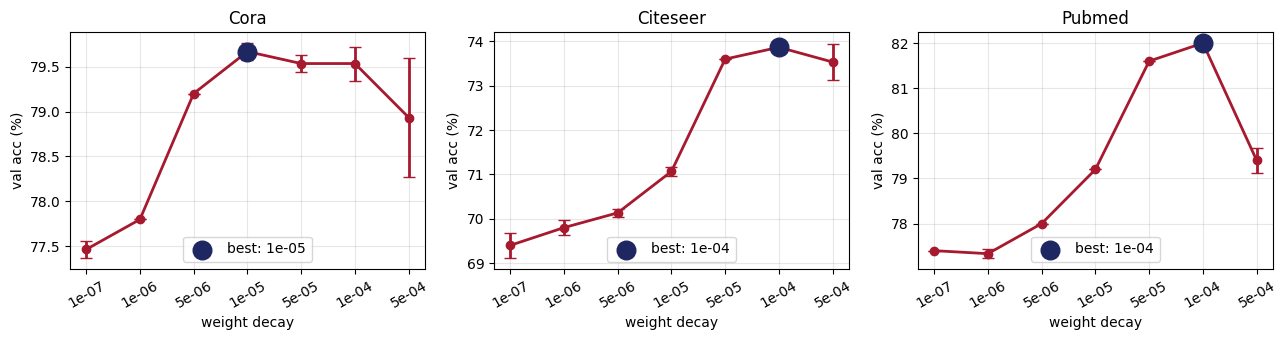

In [8]:
# Visualize the wd grid — useful for the writeup, shows tuning was actually informative
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, len(DATASETS), figsize=(13, 3.5), sharey=False)
for ax, ds in zip(axes, DATASETS):
    grid = TUNE_GRIDS[ds]
    wds = sorted(grid.keys())
    means = [grid[w][0] * 100 for w in wds]
    stds = [grid[w][1] * 100 for w in wds]
    ax.errorbar(range(len(wds)), means, yerr=stds, marker='o', capsize=4,
                color='#A6192E', linewidth=2)
    best = SGC_WD[ds]
    bi = wds.index(best)
    ax.scatter([bi], [means[bi]], s=180, color='#1E2761', zorder=5,
               label=f'best: {best:.0e}')
    ax.set_xticks(range(len(wds)))
    ax.set_xticklabels([f'{w:.0e}' for w in wds], rotation=30)
    ax.set_xlabel('weight decay')
    ax.set_ylabel('val acc (%)')
    ax.set_title(ds)
    ax.legend(loc='lower center')
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Run the full benchmark (with tuned SGC weight decay)

In [ ]:
MODELS = ['sgc', 'gcn']
SEEDS = list(range(10))

results = []
for model_name in MODELS:
    for ds in DATASETS:
        for seed in SEEDS:
            hparams = {}
            if model_name == 'sgc' and ds in SGC_WD:
                hparams['weight_decay'] = SGC_WD[ds]
            r = run_experiment(model_name, ds, seed, **hparams)
            results.append(r)
            print(f'[{model_name:>3}/{ds:<8} seed={seed}] '
                  f'test={r.test_acc*100:.2f}% '
                  f'val={r.val_acc*100:.2f}% '
                  f'epoch={r.best_epoch:3d} '
                  f'time={r.train_time:.3f}s')

[sgc/Cora     seed=0] test=80.20% val=79.60% epoch= 36 time=0.309s
[sgc/Cora     seed=1] test=80.00% val=79.60% epoch= 40 time=0.298s
[sgc/Cora     seed=2] test=79.90% val=79.80% epoch= 40 time=0.295s
[sgc/Cora     seed=3] test=79.60% val=79.40% epoch= 43 time=0.306s
[sgc/Cora     seed=4] test=79.80% val=79.60% epoch= 40 time=0.294s
[sgc/Cora     seed=5] test=79.80% val=79.80% epoch= 44 time=0.290s
[sgc/Cora     seed=6] test=79.70% val=79.60% epoch= 43 time=0.304s
[sgc/Cora     seed=7] test=79.90% val=79.60% epoch= 40 time=0.294s
[sgc/Cora     seed=8] test=80.30% val=79.80% epoch= 38 time=0.294s
[sgc/Cora     seed=9] test=80.10% val=79.80% epoch= 40 time=0.290s
[sgc/Citeseer seed=0] test=71.70% val=74.00% epoch= 45 time=0.525s
[sgc/Citeseer seed=1] test=72.00% val=73.80% epoch= 96 time=0.521s
[sgc/Citeseer seed=2] test=72.00% val=73.80% epoch= 99 time=0.506s
[sgc/Citeseer seed=3] test=72.00% val=73.80% epoch= 95 time=0.519s
[sgc/Citeseer seed=4] test=72.00% val=73.80% epoch= 96 time=0.

## 8. Independent Exploration

In [22]:
# Independent Exploration. 'Actor' dataset, a heterophilic graph where nodes are actors and
# edges connect actors who appeared on the same Wikipedia page. The classification task is
# to predict which of 5 categories each actor belongs to based on keywords from their Wikipedia
# page. Code is intended to test whether SGC's simplification holds outside the homophilic
# Planetoid datasets. Both models plateau near ~29% (5-class chance = 20%), showing the
# bottleneck is neighborhood averaging over heterophilic edges, not the presence or absence of
# nonlinearity between propagation steps.

import numpy as np
import pandas as pd
import torch
import torch_geometric.transforms as T
from torch_geometric.data import Data

from google.colab import drive
drive.mount('/content/drive')

# File paths. Replace with yours when running.
NODE_FILE   = "/content/drive/MyDrive/actor_nodes.txt"
EDGE_FILE   = "/content/drive/MyDrive/actor_edges.txt"
FEATURE_DIM = 931


def load_actor_pyg() -> Data:
    """Load Actor dataset from local txt files with the Geom-GCN 60/20/20 split."""
    node_df = pd.read_csv(NODE_FILE, sep="\t")
    feat_col = [c for c in node_df.columns if c.startswith("feature")][0]
    node_df = node_df.rename(columns={feat_col: "feature"})
    node_df = node_df.sort_values("node_id").reset_index(drop=True)
    N = len(node_df)

    x = torch.zeros(N, FEATURE_DIM, dtype=torch.float32)
    for i, row in enumerate(node_df["feature"]):
        for idx in (int(v) for v in str(row).split(",") if v.strip()):
            if idx < FEATURE_DIM:
                x[i, idx] = 1.0

    y = torch.tensor(node_df["label"].to_numpy(dtype=np.int64))

    edge_df = pd.read_csv(EDGE_FILE, sep="\t", header=0)
    edge_df.columns = ["src", "dst"]
    all_ids = sorted(node_df["node_id"].tolist())
    id_map  = {nid: i for i, nid in enumerate(all_ids)}
    src = torch.tensor([id_map[s] for s in edge_df["src"]], dtype=torch.long)
    dst = torch.tensor([id_map[d] for d in edge_df["dst"]], dtype=torch.long)
    edge_index = torch.unique(
        torch.stack([torch.cat([src, dst]), torch.cat([dst, src])], dim=0), dim=1
    )

    num_classes = int(y.max().item()) + 1

    # Geom-GCN protocol: 60/20/20 random split (Pei et al. 2020)
    # Standard heterophily benchmarking protocol; documented GCN accuracy ~26-30%
    rng        = np.random.default_rng(42)
    perm       = rng.permutation(N)
    n_tr       = int(N * 0.6)
    n_val      = int(N * 0.2)
    train_idx  = perm[:n_tr]
    val_idx    = perm[n_tr : n_tr + n_val]
    test_idx   = perm[n_tr + n_val :]

    train_mask = torch.zeros(N, dtype=torch.bool)
    val_mask   = torch.zeros(N, dtype=torch.bool)
    test_mask  = torch.zeros(N, dtype=torch.bool)
    train_mask[train_idx] = True
    val_mask[val_idx]     = True
    test_mask[test_idx]   = True

    data = Data(x=x, y=y, edge_index=edge_index,
                train_mask=train_mask, val_mask=val_mask, test_mask=test_mask)
    data.num_classes = num_classes
    data = T.NormalizeFeatures()(data)
    return data

# Patch tune_sgc_wd so it doesn't try to load Actor via Planetoid (no longer hosted on this repo)
_orig_tune_sgc_wd = tune_sgc_wd

def tune_sgc_wd(dataset_name, wd_grid=WD_GRID, tune_seeds=TUNE_SEEDS):
    if dataset_name == 'Actor':
        data = load_actor_pyg().to(device)
        grid = {}
        print(f'\nTuning SGC on {dataset_name} (grid={wd_grid}, seeds={tune_seeds}):')
        overrides = SGC_DATASET_OVERRIDES.get(dataset_name, {})
        for wd in wd_grid:
            vas = [run_sgc(data, data.num_classes, s,
                           weight_decay=wd, **overrides).val_acc
                   for s in range(tune_seeds)]
            grid[wd] = (np.mean(vas), np.std(vas))
            print(f'  wd={wd:.0e}  val={grid[wd][0]*100:.2f} ± {grid[wd][1]*100:.2f}')
        best = max(wd_grid, key=lambda w: grid[w][0])
        print(f'  → best wd = {best:.0e}')
        return best, grid
    return _orig_tune_sgc_wd(dataset_name, wd_grid=wd_grid, tune_seeds=tune_seeds)


# Patch run_experiment so the benchmark loop handles Actor
_orig_run_experiment = run_experiment

def run_experiment(model_name, dataset_name, seed, **hparams):
    if dataset_name == 'Actor':
        data = load_actor_pyg().to(device)
        if model_name.lower() == 'sgc':
            overrides = SGC_DATASET_OVERRIDES.get('Actor', {})
            res = run_sgc(data, data.num_classes, seed, **{**overrides, **hparams})
        elif model_name.lower() == 'gcn':
            res = run_gcn(data, data.num_classes, seed, **hparams)
        else:
            raise ValueError(model_name)
        res.dataset = 'Actor'
        return res
    return _orig_run_experiment(model_name, dataset_name, seed, **hparams)


if 'Actor' not in DATASETS:
    DATASETS.append('Actor')
SGC_WD['Actor'], TUNE_GRIDS['Actor'] = tune_sgc_wd('Actor')


# Benchmark for Actor dataset
for model_name in MODELS:
    for seed in SEEDS:
        hparams = {'weight_decay': SGC_WD['Actor']} if model_name == 'sgc' else {}
        r = run_experiment(model_name, 'Actor', seed, **hparams)
        results.append(r)
        print(f'[{model_name:>3}/Actor    seed={seed}] '
              f'test={r.test_acc*100:.2f}% '
              f'val={r.val_acc*100:.2f}% '
              f'epoch={r.best_epoch:3d} '
              f'time={r.train_time:.3f}s')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

Tuning SGC on Actor (grid=[1e-07, 1e-06, 5e-06, 1e-05, 5e-05, 0.0001, 0.0005], seeds=3):
  wd=1e-07  val=32.02 ± 0.03
  wd=1e-06  val=32.37 ± 0.11
  wd=5e-06  val=32.02 ± 0.03
  wd=1e-05  val=31.51 ± 0.00
  wd=5e-05  val=29.65 ± 0.08
  wd=1e-04  val=29.21 ± 0.27
  wd=5e-04  val=27.39 ± 0.19
  → best wd = 1e-06
[sgc/Actor    seed=0] test=27.50% val=32.24% epoch= 45 time=0.316s
[sgc/Actor    seed=1] test=27.57% val=32.50% epoch= 46 time=0.321s
[sgc/Actor    seed=2] test=27.96% val=32.37% epoch= 53 time=0.327s
[sgc/Actor    seed=3] test=27.57% val=32.30% epoch= 46 time=0.331s
[sgc/Actor    seed=4] test=27.63% val=32.30% epoch= 46 time=0.360s
[sgc/Actor    seed=5] test=27.83% val=32.24% epoch= 47 time=0.329s
[sgc/Actor    seed=6] test=27.96% val=32.17% epoch= 53 time=0.397s
[sgc/Actor    seed=7] test=27.83% val=32.17% epoch= 51 time=0.392s
[sgc/Actor    seed=8] 

In [23]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Experimenting with Different Levels of Homophily

## Loading Heterophilic Datasets

We tested several heterophilic datasets to evaluate SGC and GCN performance across varying homophily levels. Datasets were selected based on three criteria: availability in PyTorch Geometric, a reasonable number of nodes (comparable to citation networks), and a range of homophily ratios to provide good coverage across the spectrum.

**Datasets loaded:**
- **Cornell, Texas, Wisconsin**  university webpage networks 
- **Chameleon, Squirrel** Wikipedia page networks  Note: these datasets have been flagged for label leakage in standard splits (Platonov et al. 2023)
- **Amazon-ratings** product co-purchase network
- **WikiCS** Wikipedia computer science articles 


All datasets were loaded with row-normalized features via `NormalizeFeatures()`. Since WebKB and Wikipedia datasets do not have standard train/val/test masks, we applied a random 60/20/20 split. 

Sources: 

WebKB (Cornell, Texas, Wisconsin, Actor, Chameleon, Squirrel):
Pei, H., Wei, B., Chang, K. C. C., Lei, Y., & Yang, B. (2020). Geom-GCN: Geometric graph convolutional networks. International Conference on Learning Representations (ICLR 2020). https://arxiv.org/abs/2002.05287
Amazon-ratings:
Platonov, O., Kuznedelev, D., Diskin, M., Babenko, A., & Prokhorenkova, L. (2023). A critical look at the evaluation of GNNs under heterophily. International Conference on Learning Representations (ICLR 2023). https://arxiv.org/abs/2302.11640
WikiCS:
Mernyei, P., & Cangea, C. (2020). Wiki-CS: A Wikipedia-based benchmark for graph neural networks. arXiv preprint arXiv:2007.02901. https://arxiv.org/abs/2007.02901
Chameleon/Squirrel label leakage note:
Platonov, O., Kuznedelev, D., Diskin, M., Babenko, A., & Prokhorenkova, L. (2023). A critical look at the evaluation of GNNs under heterophily. International Conference on Learning Representations (ICLR 2023). https://arxiv.org/abs/2302.11640

In [ ]:
from torch_geometric.datasets import WebKB, WikipediaNetwork, Twitch, WikiCS, HeterophilousGraphDataset


def load_hetero_dataset(name):
    if name == 'Cornell':
        return WebKB(root='./data/Cornell', name='Cornell', transform=T.NormalizeFeatures())[0]
    elif name == 'Texas':
        return WebKB(root='./data/Texas', name='Texas', transform=T.NormalizeFeatures())[0]
    elif name == 'Chameleon':
        return WikipediaNetwork(root='./data/Chameleon', name='chameleon', transform=T.NormalizeFeatures())[0]
    elif name == 'Squirrel':
        return WikipediaNetwork(root='./data/Squirrel', name='squirrel', transform=T.NormalizeFeatures())[0]
    elif name == 'Wisconsin':
        return WebKB(root='./data/Wisconsin', name='Wisconsin', transform=T.NormalizeFeatures())[0]
    elif name == 'WikiCS':
      return WikiCS(root='./data/WikiCS', transform=T.NormalizeFeatures())[0]
    elif name == 'Amazon':
      return HeterophilousGraphDataset(root='./data/amazon', name='amazon-ratings', transform=T.NormalizeFeatures())[0]
    else:
        raise ValueError(f'Unknown dataset: {name}')

def compute_homophily(data):
    row, col = data.edge_index
    same_class = (data.y[row] == data.y[col]).float()
    return same_class.mean().item()

### Selecting the Heterophilic Datasets

To select the most comparable heterophilic graphs to the citation networks, we printed out the number of nodes, edges, and classes for each candidate dataset. We then selected datasets with a similar number of classes (3-7) and a comparable graph size to Cora, Citeseer, and Pubmed (2K-25K nodes). This was our attempt to avoid confounding factors like drastically different class counts or graph sizes. 

We selected the following:  'Cora', 'Citeseer', 'Pubmed', 'Actor', 'Amazon', 'Chameleon', 'Squirrel'


In [ ]:
import pandas as pd

datasets_to_check = ['Cora', 'Citeseer', 'Pubmed', 'Actor', 'Amazon', 'Chameleon', 'Squirrel', 'Cornell', 'Texas', 'Wisconsin']

dataset_info = []

for ds in datasets_to_check:
    sub = [r for r in results if r.dataset == ds]
    if ds in ['Cora', 'Citeseer', 'Pubmed']:
        data = Planetoid(root=f'./data/{ds}', name=ds)[0]
    elif ds == 'Actor':
        data = load_actor_pyg()
    else:
        data = load_hetero_dataset(ds)

    num_nodes = data.num_nodes
    num_edges = data.num_edges
    num_classes = int(data.y.max().item()) + 1 if data.y.dim() > 0 else 0

    dataset_info.append({
        'Dataset': ds,
        'Nodes': num_nodes,
        'Classes': num_classes,
        'Edges': num_edges,
        'Homophily': f'{homophily:.3f}' if isinstance(homophily, float) else homophily
    })

df_info = pd.DataFrame(dataset_info)
print(df_info.to_markdown(index=False))


| Dataset   |   Nodes |   Classes |   Edges | Homophily   |
|:----------|--------:|----------:|--------:|:------------|
| Cora      |    2708 |         7 |   10556 | 0.810       |
| Citeseer  |    3327 |         6 |    9104 | 0.736       |
| Pubmed    |   19717 |         3 |   88648 | 0.802       |
| Actor     |    7600 |         5 |   53411 | 0.218       |
| Amazon    |   24492 |         5 |  186100 | 0.380       |
| Chameleon |    2277 |         5 |   36101 | 0.235       |
| Squirrel  |    5201 |         5 |  217073 | 0.224       |
| Cornell   |     183 |         5 |     298 | N/A         |
| Texas     |     183 |         5 |     325 | N/A         |
| Wisconsin |     251 |         5 |     515 | N/A         |


### Experiment with 10 RUNS

In [ ]:

SELECTED_HETERO_DATASETS = ['Chameleon' ,'Amazon', 'Squirrel']

def add_random_split(data, seed=42):
    N = data.num_nodes
    rng = np.random.default_rng(seed)
    perm = rng.permutation(N)
    n_tr  = int(N * 0.6)
    n_val = int(N * 0.2)
    train_mask = torch.zeros(N, dtype=torch.bool)
    val_mask   = torch.zeros(N, dtype=torch.bool)
    test_mask  = torch.zeros(N, dtype=torch.bool)
    train_mask[perm[:n_tr]]            = True
    val_mask[perm[n_tr:n_tr + n_val]]  = True
    test_mask[perm[n_tr + n_val:]]     = True
    data.train_mask = train_mask
    data.val_mask   = val_mask
    data.test_mask  = test_mask
    return data

# patch run_experiment to handle new datasets
_orig_run_experiment2 = run_experiment

def run_experiment(model_name, dataset_name, seed, **hparams):
    if dataset_name in SELECTED_HETERO_DATASETS:
        data = load_hetero_dataset(dataset_name)
        data = add_random_split(data, seed=seed)
        data = data.to(device)
        num_classes = int(data.y.max().item()) + 1
        if model_name.lower() == 'sgc':
            overrides = SGC_DATASET_OVERRIDES.get(dataset_name, {})
            res = run_sgc(data, num_classes, seed, **{**overrides, **hparams})
        else:
            res = run_gcn(data, num_classes, seed, **hparams)
        res.dataset = dataset_name
        return res
    return _orig_run_experiment2(model_name, dataset_name, seed, **hparams)

# tune weight decay for new datasets
for ds in SELECTED_HETERO_DATASETS:
    data = load_hetero_dataset(ds)
    data = add_random_split(data)
    data = data.to(device)
    num_classes = int(data.y.max().item()) + 1
    grid = {}
    for wd in WD_GRID:
        vas = [run_sgc(data, num_classes, s, weight_decay=wd).val_acc
               for s in range(TUNE_SEEDS)]
        grid[wd] = (np.mean(vas), np.std(vas))
    best = max(WD_GRID, key=lambda w: grid[w][0])
    SGC_WD[ds] = best
    print(f'{ds}: best wd = {best:.0e}')

# run full benchmark on heterophilic datasets
for model_name in MODELS:
    for ds in SELECTED_HETERO_DATASETS:
        for seed in SEEDS:
            hparams = {'weight_decay': SGC_WD[ds]} if model_name == 'sgc' else {}
            r = run_experiment(model_name, ds, seed, **hparams)
            results.append(r)
            print(f'[{model_name:>3}/{ds:<10} seed={seed}] '
                  f'test={r.test_acc*100:.2f}%  time={r.train_time:.3f}s')

Chameleon: best wd = 1e-06
Amazon: best wd = 1e-07
Squirrel: best wd = 1e-07
[sgc/Chameleon  seed=0] test=60.09%  time=0.331s
[sgc/Chameleon  seed=1] test=58.99%  time=0.347s
[sgc/Chameleon  seed=2] test=59.65%  time=0.352s
[sgc/Chameleon  seed=3] test=60.53%  time=0.335s
[sgc/Chameleon  seed=4] test=62.72%  time=0.330s
[sgc/Chameleon  seed=5] test=57.68%  time=0.379s
[sgc/Chameleon  seed=6] test=60.53%  time=0.381s
[sgc/Chameleon  seed=7] test=64.04%  time=0.344s
[sgc/Chameleon  seed=8] test=59.65%  time=0.300s
[sgc/Chameleon  seed=9] test=61.62%  time=0.296s
[sgc/Amazon     seed=0] test=36.40%  time=0.324s
[sgc/Amazon     seed=1] test=37.03%  time=0.341s
[sgc/Amazon     seed=2] test=36.80%  time=0.823s
[sgc/Amazon     seed=3] test=35.99%  time=0.323s
[sgc/Amazon     seed=4] test=36.82%  time=0.321s
[sgc/Amazon     seed=5] test=36.86%  time=0.330s
[sgc/Amazon     seed=6] test=36.80%  time=0.330s
[sgc/Amazon     seed=7] test=36.54%  time=0.322s
[sgc/Amazon     seed=8] test=36.17%  time

### Plot Results

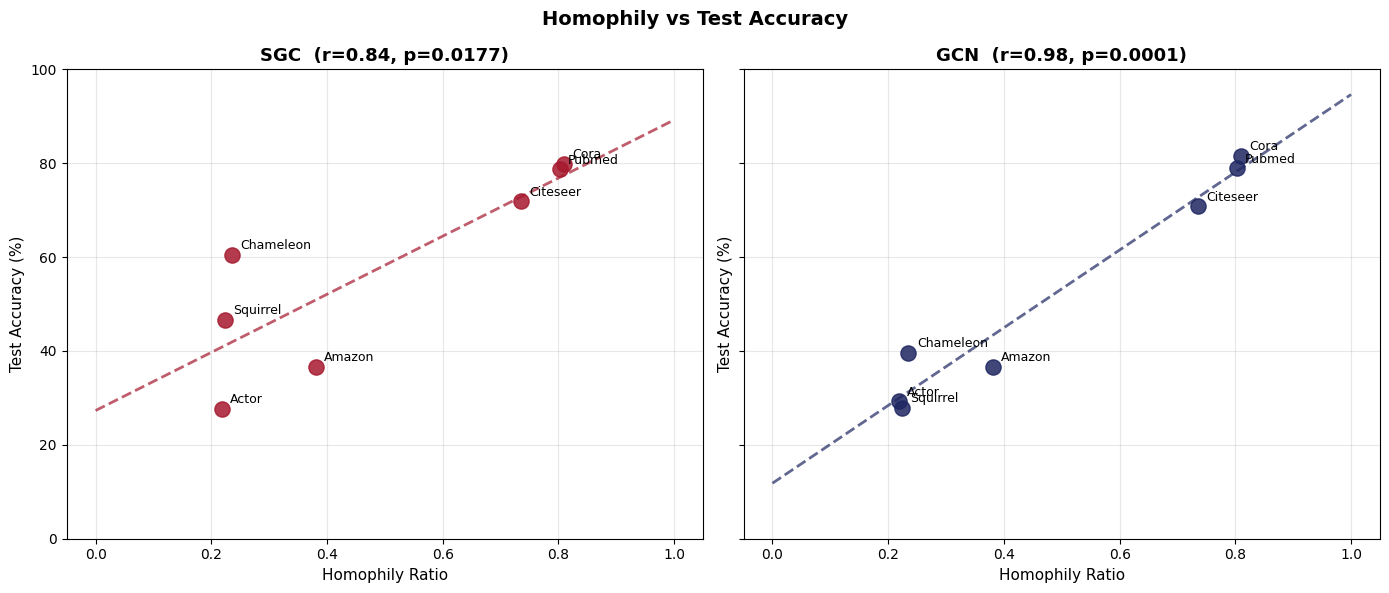

In [ ]:
from scipy import stats
import matplotlib.lines as mlines

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

datasets_to_use = ['Actor', 'Chameleon', 'Squirrel', 'Amazon', 'Citeseer', 'Cora', 'Pubmed']

for ax, (model, color) in zip(axes, colors.items()):
    hom_vals, acc_vals = [], []
    for ds in datasets_to_use:
        sub = [r for r in results if r.model.upper() == model and r.dataset == ds]
        if not sub:
            continue
        acc = np.mean([r.test_acc for r in sub]) * 100
        hom_vals.append(homophily_vals[ds])
        acc_vals.append(acc)
        ax.scatter(homophily_vals[ds], acc, color=color, s=120, zorder=3, alpha=0.85)
        ax.annotate(ds, (homophily_vals[ds], acc),
                    textcoords='offset points', xytext=(6, 4), fontsize=9)

    m, b, r, p, _ = stats.linregress(hom_vals, acc_vals)
    x_line = np.linspace(0, 1, 100)
    ax.plot(x_line, m * x_line + b, color=color,
            linewidth=2, linestyle='--', alpha=0.7)

    ax.set_title(f'{model}  (r={r:.2f}, p={p:.4f})', fontsize=13, fontweight='bold')
    ax.set_xlabel('Homophily Ratio', fontsize=11)
    ax.set_ylabel('Test Accuracy (%)', fontsize=11)
    ax.set_xlim(-0.05, 1.05)
    ax.set_ylim(0, 100)
    ax.grid(alpha=0.3)

fig.suptitle('Homophily vs Test Accuracy', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('homophily_scatter_final.png', dpi=150, bbox_inches='tight')
plt.show()

### Significance of Homophily in Predicting Test Accuracy

To quantify whether homophily predicts model performance, we computed the Pearson correlation between each dataset's homophily ratio and mean test accuracy across 10 seeds, using `scipy.stats.pearsonr` across 7 datasets spanning homophily ratios from 0.22 to 0.81.

In [106]:
from scipy import stats
import numpy as np

print(f"{'Model':<6} {'r':>8} {'p-value':>10} {'significant':>12}")
print('-' * 40)

for model in ['SGC', 'GCN']:
    hom_vals, acc_vals = [], []
    for ds in datasets_to_use:
        sub = [r for r in results if r.model.upper() == model and r.dataset == ds]
        if not sub:
            continue
        acc = np.mean([r.test_acc for r in sub]) * 100
        hom_vals.append(homophily_vals[ds])
        acc_vals.append(acc)

    r, p = stats.pearsonr(hom_vals, acc_vals)
    sig = 'yes' if p < 0.05 else 'no'
    print(f'{model:<6} {r:>8.3f} {p:>10.4f} {sig:>12}')

    # also print the data points so you can verify
    print(f'  datasets: {list(zip([d for d in datasets_to_use if any(r.dataset==d for r in results)], hom_vals, [f"{a:.1f}%" for a in acc_vals]))}')
    print()

Model         r    p-value  significant
----------------------------------------
SGC       0.841     0.0177          yes
  datasets: [('Actor', 0.2181011438369751, '27.7%'), ('Chameleon', 0.23500734567642212, '60.5%'), ('Squirrel', 0.2239430993795395, '46.6%'), ('Amazon', 0.3803761303424835, '36.6%'), ('Citeseer', 0.7355008721351624, '71.9%'), ('Cora', 0.8099659085273743, '79.9%'), ('Pubmed', 0.8023869395256042, '78.7%')]

GCN       0.981     0.0001          yes
  datasets: [('Actor', 0.2181011438369751, '29.3%'), ('Chameleon', 0.23500734567642212, '39.6%'), ('Squirrel', 0.2239430993795395, '27.9%'), ('Amazon', 0.3803761303424835, '36.6%'), ('Citeseer', 0.7355008721351624, '70.8%'), ('Cora', 0.8099659085273743, '81.6%'), ('Pubmed', 0.8023869395256042, '78.9%')]



## 9. Summary table of Results

In [108]:
import pandas as pd
rows = []
for model in MODELS:
    for ds in ALL_DATASETS:
        sub = [r for r in results if r.model.lower() == model and r.dataset == ds]
        accs = np.array([r.test_acc for r in sub]) * 100
        times = np.array([r.train_time for r in sub])
        rows.append({
            'Model': model.upper(), 'Dataset': ds,
            'Test Acc': f'{accs.mean():.1f} ± {accs.std():.1f}',
            'Train Time (s)': f'{times.mean():.3f} ± {times.std():.3f}',
            'N': len(sub),
        })
df = pd.DataFrame(rows)
df

,Model,Dataset,Test Acc,Train Time (s),N
0,SGC,Cora,79.9 ± 0.2,0.297 ± 0.006,10
1,SGC,Citeseer,71.9 ± 0.2,0.515 ± 0.010,10
2,SGC,Pubmed,78.7 ± 0.1,0.360 ± 0.039,10
3,SGC,Actor,27.7 ± 0.2,0.353 ± 0.030,10
4,SGC,Chameleon,60.5 ± 1.7,0.317 ± 0.032,80
5,SGC,Amazon,36.6 ± 0.3,0.359 ± 0.066,70
6,SGC,Squirrel,46.6 ± 0.9,0.392 ± 0.034,80
7,GCN,Cora,81.6 ± 0.6,0.785 ± 0.111,10
8,GCN,Citeseer,70.8 ± 0.8,0.879 ± 0.101,10
9,GCN,Pubmed,78.9 ± 0.7,0.716 ± 0.109,10
